# 11 — Calibration & Continuous Learning

Phase 1 of the attack plan: calibration diagnostics (G-11) + distribution-shift experiment using G-4 online representation updates and G-5 forgetting factor.

Runs end-to-end on CPU in a few minutes with the 20 000-row synthetic cohort.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from loguru import logger

from src.data_generator import (
    TREATMENTS, N_TREATMENTS, IDX_TO_TREATMENT, REWARD_CAP_PP,
    generate_patient, reward_oracle, generate_bandit_dataset,
)
from src.feature_engineering import get_scaled_pipeline, ALL_FEATURES
from src.neural_bandit import NeuralThompson
from src.evaluation import (
    expected_calibration_error, reliability_diagram, confidence_label_accuracy,
)

import warnings
import traceback

def warn_with_traceback(message, category, filename, lineno, file=None, line=None):
    log = file if hasattr(file, 'write') else __import__('sys').stderr
    traceback.print_stack(file=log)
    log.write(warnings.formatwarning(message, category, filename, lineno, line))

warnings.showwarning = warn_with_traceback

np.random.seed(42)

## 1. Train NeuralThompson with counterfactual MSE (G-2)
Using the full 5-head counterfactual matrix gives 5× the signal of partial feedback.

In [2]:
df = pd.read_csv('../data/bandit_dataset.csv')
print(f'rows: {len(df)}')

cf_cols = [f'reward_{k}' for k in range(N_TREATMENTS)]
counterfactuals = df[cf_cols].to_numpy(dtype=float)
actions = df['action'].astype(int).to_numpy()
rewards = df['reward'].astype(float).to_numpy()

pipe = get_scaled_pipeline()
X = pipe.fit_transform(df)

# 80/20 split
n_train = int(0.8 * len(X))
X_train, X_val = X[:n_train], X[n_train:]
a_train, a_val = actions[:n_train], actions[n_train:]
r_train, r_val = rewards[:n_train], rewards[n_train:]
cf_train, cf_val = counterfactuals[:n_train], counterfactuals[n_train:]

model = NeuralThompson(
    input_dim=X.shape[1], hidden_dims=[128, 64], dropout=0.1,
    reg_lambda=1.0, noise_variance=0.25, forgetting_factor=0.999,
)
model.train(X_train, a_train, r_train, counterfactuals=cf_train,
            epochs=30, verbose=False)

# G-10: calibrate σ² from residuals, then G-1: bootstrap the posterior.
sigma2 = model.noise_variance_from_residuals(X_val, a_val, r_val)
print(f'noise_variance from residuals = {sigma2:.4f}')
model.initialize_posterior(X_train, a_train, r_train)

2026-04-16 06:50:01.921 | INFO     | src.feature_engineering:fit:158 - FeaturePipeline fitted: 25 features, scale=True


rows: 20000


2026-04-16 06:50:03.082 | INFO     | src.neural_bandit:__init__:158 - NeuralThompson initialized: input=25, hidden=[128, 64], device=cpu
2026-04-16 06:50:15.963 | INFO     | src.neural_bandit:train:291 - Training complete: best_val_loss=0.0197, epochs_run=30
2026-04-16 06:50:15.967 | INFO     | src.neural_bandit:noise_variance_from_residuals:950 - noise_variance ← 0.0321 (estimated from residuals)


noise_variance from residuals = 0.0321


2026-04-16 06:50:16.840 | INFO     | src.neural_bandit:initialize_posterior:922 - Posterior bootstrapped from 16000 rows (G-1 fix).


## 2. Calibration diagnostics (G-11)

Compute per-patient confidence on the held-out set, then plot a reliability diagram and report ECE + bucketed accuracy by confidence label.

In [3]:
optimal_actions = counterfactuals.argmax(axis=1)

conf_pcts = []
conf_labels = []
correctness = []
for i in range(len(X_val)):
    out = model.compute_confidence(X_val[i], n_draws=200)
    conf_pcts.append(out['confidence_pct'])
    conf_labels.append(out['confidence_label'])
    correctness.append(int(out['recommended_idx'] == optimal_actions[n_train + i]))

conf_pcts = np.array(conf_pcts)
conf_labels = np.array(conf_labels)
correctness = np.array(correctness)

ece = expected_calibration_error(conf_pcts, correctness, n_bins=10)
bucketed = confidence_label_accuracy(conf_labels, correctness)
print(f'ECE = {ece:.3f} (target < 0.05)')
for lab, stats in bucketed.items():
    print(f'  {lab}: n={stats["n"]}, accuracy={stats["accuracy"]:.3f}')

ECE = 0.100 (target < 0.05)
  HIGH: n=3795, accuracy=0.901
  MODERATE: n=161, accuracy=0.516
  LOW: n=44, accuracy=0.409


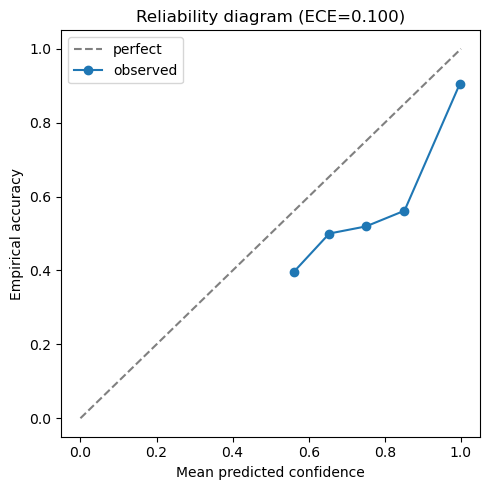

In [4]:
diag = reliability_diagram(conf_pcts, correctness, n_bins=10)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='perfect')
mask = diag['bin_counts'] > 0
ax.plot(diag['bin_confidence'][mask], diag['bin_accuracy'][mask],
        marker='o', label='observed')
ax.set_xlabel('Mean predicted confidence')
ax.set_ylabel('Empirical accuracy')
ax.set_title(f'Reliability diagram (ECE={ece:.3f})')
ax.legend(); plt.tight_layout(); plt.show()

## 3. Distribution shift with online representation updates (G-4)

Inject a BMI shift halfway through 10 000 rounds; the online retrain loop
should recover within a few thousand steps.

2026-04-16 06:50:18.658 | INFO     | src.neural_bandit:enable_online_retraining:831 - Online retraining enabled: buffer=5000, retrain_every=1000, minibatch=512
2026-04-16 06:50:25.008 | INFO     | src.neural_bandit:initialize_posterior:922 - Posterior bootstrapped from 1000 rows (G-1 fix).
2026-04-16 06:50:25.009 | INFO     | src.neural_bandit:_periodic_retrain:864 - Periodic retrain @step 1000: backbone updated on 512 samples, posterior rebuilt from 1000 buffered transitions.
2026-04-16 06:50:31.339 | INFO     | src.neural_bandit:initialize_posterior:922 - Posterior bootstrapped from 2000 rows (G-1 fix).
2026-04-16 06:50:31.341 | INFO     | src.neural_bandit:_periodic_retrain:864 - Periodic retrain @step 2000: backbone updated on 512 samples, posterior rebuilt from 2000 buffered transitions.
2026-04-16 06:50:37.736 | INFO     | src.neural_bandit:initialize_posterior:922 - Posterior bootstrapped from 3000 rows (G-1 fix).
2026-04-16 06:50:37.737 | INFO     | src.neural_bandit:_periodic_

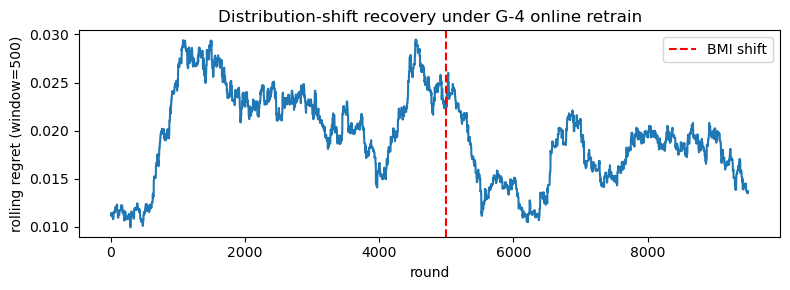

In [5]:
model.enable_online_retraining(
    buffer_size=5_000, retrain_every=1_000, minibatch_size=512,
    retrain_epochs=1, min_buffer_for_retrain=1_000,
)

rng = np.random.default_rng(0)
N_ROUNDS = 10_000
SHIFT_AT = N_ROUNDS // 2
BMI_SHIFT = 4.0
regrets = np.zeros(N_ROUNDS)

for t in range(N_ROUNDS):
    ctx = generate_patient(rng)
    if t >= SHIFT_AT:
        ctx['bmi'] = min(55.0, ctx['bmi'] + BMI_SHIFT)
    x = pipe.transform_single(ctx)                    # ← replaces the two lines below
    # df_row = pd.DataFrame([ctx])                    # ← removed
    # x = pipe.transform(df_row)[0]                  # ← removed
    out = model.compute_confidence(x, n_draws=50)
    action = out['recommended_idx']
    rewards_oracle = np.array([
        reward_oracle(ctx, IDX_TO_TREATMENT[k], noise=False)
        for k in range(N_TREATMENTS)
    ])
    r = float(reward_oracle(ctx, IDX_TO_TREATMENT[action], noise=True))
    regrets[t] = rewards_oracle.max() - rewards_oracle[action]
    model.online_update(x, action, r)

window = 500
rolling = np.convolve(regrets, np.ones(window) / window, mode='valid')
plt.figure(figsize=(8, 3))
plt.plot(rolling)
plt.axvline(SHIFT_AT, color='red', linestyle='--', label='BMI shift')
plt.xlabel('round'); plt.ylabel(f'rolling regret (window={window})')
plt.title('Distribution-shift recovery under G-4 online retrain')
plt.legend(); plt.tight_layout(); plt.show()